In [2]:

import gymnasium as gym
import matplotlib
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
import torch
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import namedtuple, deque
from itertools import count
import random
import math
import pickle

is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display
plt.ion()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:

def image_preprocessing(img):
  img = cv2.resize(img, dsize=(84, 84))
  img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) / 255.0
  return img

In [4]:
class CarEnvironment(gym.Wrapper):
  def __init__(self, env, skip_frames=3, stack_frames=4, no_operation=50, **kwargs):
    super().__init__(env, **kwargs)
    self._no_operation = no_operation
    self._skip_frames = skip_frames
    self._stack_frames = stack_frames

  def reset(self):
    observation, info = self.env.reset()

    for i in range(self._no_operation):
      observation, reward, terminated, truncated, info = self.env.step(0)

    observation = image_preprocessing(observation)
    self.stack_state = np.tile(observation, (self._stack_frames, 1, 1))
    return self.stack_state, info


  def step(self, action):
    total_reward = 0
    for i in range(self._skip_frames):
      observation, reward, terminated, truncated, info = self.env.step(action)
      total_reward += reward
      if terminated or truncated:
        break

    observation = image_preprocessing(observation)
    self.stack_state = np.concatenate((self.stack_state[1:], observation[np.newaxis]), axis=0)
    return self.stack_state, total_reward, terminated, truncated, info

In [1]:
class CNN(nn.Module):
  def __init__(self, in_channels, out_channels, *args, **kwargs):
    super().__init__(*args, **kwargs)
    self._n_features = 32 * 9 * 9

    self.conv = nn.Sequential(
        nn.Conv2d(in_channels, 16, kernel_size=8, stride=4),
        nn.ReLU(),
        nn.Conv2d(16, 32, kernel_size=4, stride=2),
        nn.ReLU(),
    )

    self.fc = nn.Sequential(
        nn.Linear(self._n_features, 256),
        nn.ReLU(),
        nn.Linear(256, out_channels),
    )


  def forward(self, x):
    x = self.conv(x)
    x = x.view((-1, self._n_features))
    x = self.fc(x)
    return x
     

NameError: name 'nn' is not defined

In [6]:
Transition = namedtuple('Transition', ('state', 'action', 'next_state', 'reward'))

class ReplayMemory(object):

    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

In [7]:
class DQN:
  def __init__(self, action_space, batch_size=256, gamma=0.99, eps_start=0.9, eps_end=0.05, eps_decay=1000, lr=0.001):
    self._n_observation = 4
    self._n_actions = 5
    self._action_space = action_space
    self._batch_size = batch_size
    self._gamma = gamma
    self._eps_start = eps_start
    self._eps_end = eps_end
    self._eps_decay = eps_decay
    self._lr = lr
    self._total_steps = 0
    self._evaluate_loss = []
    self.network = CNN(self._n_observation, self._n_actions).to(device)
    self.target_network = CNN(self._n_observation, self._n_actions).to(device)
    self.target_network.load_state_dict(self.network.state_dict())
    self.optimizer = optim.AdamW(self.network.parameters(), lr=self._lr, amsgrad=True)
    self._memory = ReplayMemory(10000)

  """
  This function is called during training & evaluation phase when the agent
  interact with the environment and needs to select an action.

  (1) Exploitation: This function feeds the neural network a state
  and then it selects the action with the highest Q-value.
  (2) Evaluation mode: This function feeds the neural network a state
  and then it selects the action with the highest Q'-value.
  (3) Exploration mode: It randomly selects an action through sampling

  Q -> network (policy)
  Q'-> target network (best policy)
  """
  def select_action(self, state, evaluation_phase=False):

    # Generating a random number for eploration vs exploitation
    sample = random.random()

    # Calculating the threshold - the more steps the less exploration we do
    eps_threshold = self._eps_end + (self._eps_start - self._eps_end) * math.exp(-1. * self._total_steps / self._eps_decay)
    self._total_steps += 1

    if evaluation_phase:
      with torch.no_grad():
        return self.target_network(state).max(1).indices.view(1, 1)
    elif sample > eps_threshold:
      with torch.no_grad():
        return self.network(state).max(1).indices.view(1, 1)
    else:
      return torch.tensor([[self._action_space.sample()]], device=device, dtype=torch.long)

  """
  This function trains the agent
  """
  def train(self):

    if len(self._memory) < self._batch_size:
        return

    # Initializing our memory
    transitions = self._memory.sample(self._batch_size)

    # Initializing our batch
    batch = Transition(*zip(*transitions))

    # Saving in a new tensor all the indices of the states that are non terminal
    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None, batch.next_state)), device=device, dtype=torch.bool)

    # Saving in a new tensor all the non final next states
    non_final_next_states = torch.cat([s for s in batch.next_state if s is not None])

    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

    # Feeding our Q network the batch with states and then we gather the Q values of the selected actions
    state_action_values = self.network(state_batch).gather(1, action_batch)

    # We then, for every state in the batch that is NOT final, we pass it in the target network to get the Q'-values and choose the max one
    next_state_values = torch.zeros(self._batch_size, device=device)
    with torch.no_grad():
        next_state_values[non_final_mask] = self.target_network(non_final_next_states).max(1).values

    # Computing the expecting values with: reward + gamma * max(Q')
    expected_state_action_values = (next_state_values * self._gamma) + reward_batch

    # Defining our loss criterion
    criterion = nn.SmoothL1Loss()
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

    # Updating with back propagation
    self.optimizer.zero_grad()
    loss.backward()

    torch.nn.utils.clip_grad_value_(self.network.parameters(), 100)
    self.optimizer.step()

    self._evaluate_loss.append(loss.item())

    return

  def copy_weights(self):
    self.target_network.load_state_dict(self.network.state_dict())

  def get_loss(self):
    return self._evaluate_loss

  def save_model(self, i):
    torch.save(self.target_network.state_dict(), f'model_weights_{i}.pth')

  def load_model(self, i):
    self.target_network.load_state_dict(torch.load(f'model_weights_{i}.pth'))


In [8]:
rewards_per_episode = []
episode_duration = []
average_episode_loss = []

episodes = 1000
C = 5

env = gym.make('CarRacing-v2', continuous=False)
n_actions = env.action_space
agent = DQN(n_actions)

for episode in range(1, episodes + 1):

  if episode % 10 == 0:
    print(f"{episode} episodes done")

  env = gym.make('CarRacing-v2', continuous=False)
  env = CarEnvironment(env)

  state, info = env.reset()

  state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)

  episode_total_reward = 0

  for t in count():
    action = agent.select_action(state)
    observation, reward, terminated, truncated, _ = env.step(action.item())
    reward = torch.tensor([reward], device=device)
    episode_total_reward += reward
    done = terminated or truncated

    if terminated:
      next_state = None
      print("Finished the lap successfully!")
    else:
      next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)

    agent._memory.push(state, action, next_state, reward)

    state = next_state

    agent.train()

    if done:
      if agent._memory.__len__() >= 128:
        episode_duration.append(t + 1)
        rewards_per_episode.append(episode_total_reward)
        ll = agent.get_loss()
        average_episode_loss.append(sum(ll) / len(ll))
      break

    if episode % 100 == 0:
      agent.save_model(episode)
      with open('statistics.pkl', 'wb') as f:
        pickle.dump((episode_duration, rewards_per_episode, average_episode_loss), f)


  if episode % C == 0:
    agent.copy_weights()

agent.save_model(episodes)
with open('statistics.pkl', 'wb') as f:
  pickle.dump((episode_duration, rewards_per_episode, average_episode_loss), f)

10 episodes done
20 episodes done
30 episodes done
Finished the lap successfully!
Finished the lap successfully!
Finished the lap successfully!
40 episodes done
Finished the lap successfully!
Finished the lap successfully!
Finished the lap successfully!
50 episodes done
Finished the lap successfully!
Finished the lap successfully!
60 episodes done
70 episodes done
80 episodes done
90 episodes done
100 episodes done
Finished the lap successfully!
110 episodes done
120 episodes done
130 episodes done
140 episodes done
150 episodes done
160 episodes done
Finished the lap successfully!
170 episodes done
180 episodes done
190 episodes done
200 episodes done
210 episodes done
220 episodes done
230 episodes done
240 episodes done
250 episodes done
260 episodes done
270 episodes done
280 episodes done
290 episodes done
Finished the lap successfully!
Finished the lap successfully!
300 episodes done
310 episodes done
320 episodes done
330 episodes done
340 episodes done
350 episodes done
360 epi

In [9]:
def plot_statistics(x, y, title, x_axis, y_axis):
  plt.plot(x, y)
  plt.xlabel(x_axis)
  plt.ylabel(y_axis)
  plt.title(title)
  plt.grid(True)
  plt.savefig(f'{title}.png')
  plt.show()
     

In [17]:

eval_env = gym.make('CarRacing-v2', continuous=False, render_mode='rgb_array')
eval_env = CarEnvironment(eval_env)

frames = []
scores = 0
s, _ = eval_env.reset()

eval_env.np_random = np.random.default_rng(42)

done, ret = False, 0

while not done:
    frames.append(eval_env.render())
    s = torch.tensor(s, dtype=torch.float32, device=device).unsqueeze(0)
    a = agent.select_action(s, evaluation_phase=True)
    discrete_action = a.item() % 5
    s_prime, r, terminated, truncated, info = eval_env.step(discrete_action)
    s = s_prime
    ret += r
    done = terminated or truncated
    if terminated:
      print(terminated)
scores += ret


def animate(imgs, video_name, _return=True):
    import cv2
    import os
    import string
    import random

    if video_name is None:
        video_name = ''.join(random.choice(string.ascii_letters) for i in range(18)) + '.webm'
    height, width, layers = imgs[0].shape
    fourcc = cv2.VideoWriter_fourcc(*'VP90')
    video = cv2.VideoWriter(video_name, fourcc, 10, (width, height))

    for img in imgs:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        video.write(img)
    video.release()

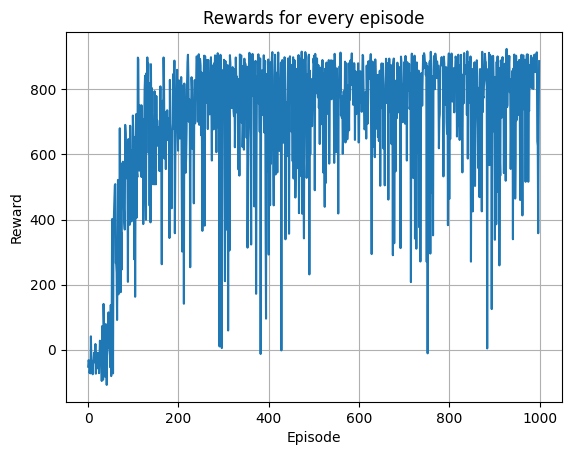

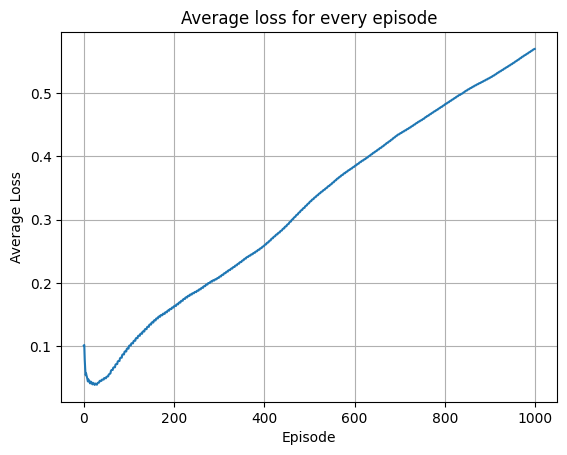

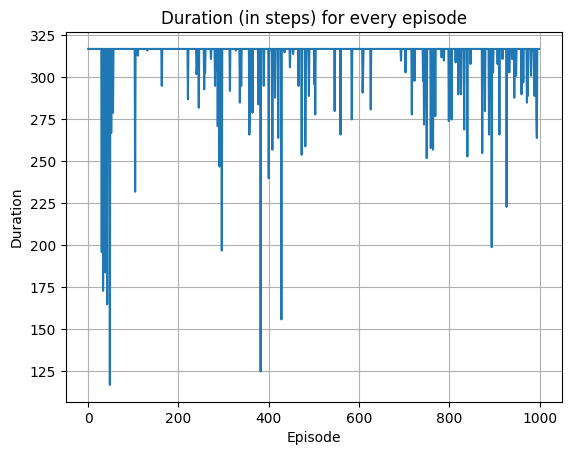

In [20]:
animate(frames, None)

with open('statistics.pkl', 'rb') as f:
    data_tuple = pickle.load(f)

episode_duration, rewards_per_episode, average_episode_loss = data_tuple

# x 리스트의 길이를 rewards_per_episode와 동일하게 설정
x = [k for k in range(len(rewards_per_episode))]

# GPU 텐서가 있을 경우 CPU로 변환
rewards_per_episode = [tensor.cpu().numpy() if isinstance(tensor, torch.Tensor) else tensor for tensor in rewards_per_episode]
average_episode_loss = [tensor.cpu().numpy() if isinstance(tensor, torch.Tensor) else tensor for tensor in average_episode_loss]
episode_duration = [tensor.cpu().numpy() if isinstance(tensor, torch.Tensor) else tensor for tensor in episode_duration]

# 통계 데이터 플롯
plot_statistics(x, rewards_per_episode, "Rewards for every episode", "Episode", "Reward")
plot_statistics(x, average_episode_loss, "Average loss for every episode", "Episode", "Average Loss")
plot_statistics(x, episode_duration, "Duration (in steps) for every episode", "Episode", "Duration")
